# Employee Data Analysis

This notebook explores employee data to identify salary patterns, data quality issues, and key business insights.

## 1. Setup

Este projeto utiliza as seguintes bibliotecas para análise e visualização de dados:

- pandas → manipulação de dados
- matplotlib → visualização
- numpy → operações numéricas

O objetivo é garantir um ambiente simples, replicável e alinhado com boas práticas de projetos de Data Analysis.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

STANDARD_FIGSIZE = (8, 4)
TITLE_SIZE = 14
LABEL_SIZE = 11

def format_plot(title, xlabel=None, ylabel=None):
    plt.title(title, fontsize=TITLE_SIZE, weight="bold")
    
    if xlabel:
        plt.xlabel(xlabel, fontsize=LABEL_SIZE)
    if ylabel:
        plt.ylabel(ylabel, fontsize=LABEL_SIZE)

    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()

## 2. Data Loading

Para análise final, utilizamos a versão já processada dos dados, localizada em `data/processed`.

Essa versão já passou por:
- Limpeza
- Padronização
- Validação

In [45]:
df = pd.read_csv("../data/processed/employees_cleaned.csv")
df.head()

,first_name,last_name,full_name,email,phone,gender,age,job_title,years_of_experience,salary,department,email_valid,phone_clean,phone_valid,phone_error
0,Jose,Lopez,Jose Lopez,joselopez0944@slingacademy.com,+1-971-533-4552x1542,male,25,Project Manager,1,8500,Product,True,1.971533e+10,True,NaN
1,Diane,Carter,Diane Carter,dianecarter1228@slingacademy.com,881.633.0107,female,26,Machine Learning Engineer,2,7000,Product,True,1.881633e+10,True,NaN
2,Shawn,Foster,Shawn Foster,shawnfoster2695@slingacademy.com,001-966-861-0065x493,male,37,Project Manager,14,17000,Product,True,NaN,False,invalid_length
3,Brenda,Fisher,Brenda Fisher,brendafisher3185@slingacademy.com,001-574-564-4648,female,31,Web Developer,8,10000,Product,True,NaN,False,invalid_length
4,Sean,Hunter,Sean Hunter,seanhunter4753@slingacademy.com,5838355842,male,35,Project Manager,11,14500,Product,True,1.583836e+10,True,NaN


## 3. Data Overview

O dataset contém informações de mais de **300 colaboradores**, incluindo:

- Dados demográficos (gênero, idade)
- Informações profissionais (cargo, departamento)
- Métricas de experiência (anos de experiência)
- Dados financeiros (salário)
- Dados de contato (email, telefone)

Antes da análise, os dados passaram por um processo de **limpeza e validação**, garantindo maior confiabilidade nos insights gerados.

In [46]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   first_name           320 non-null    str    
 1   last_name            320 non-null    str    
 2   full_name            320 non-null    str    
 3   email                320 non-null    str    
 4   phone                320 non-null    str    
 5   gender               320 non-null    str    
 6   age                  320 non-null    int64  
 7   job_title            320 non-null    str    
 8   years_of_experience  320 non-null    int64  
 9   salary               320 non-null    int64  
 10  department           320 non-null    str    
 11  email_valid          320 non-null    bool   
 12  phone_clean          257 non-null    float64
 13  phone_valid          320 non-null    bool   
 14  phone_error          63 non-null     str    
dtypes: bool(2), float64(1), int64(3), str(9)
memory usa

,age,years_of_experience,salary,phone_clean
count,320.000000,320.000000,320.000000,2.570000e+02
mean,31.587500,7.687500,10175.000000,1.494083e+10
std,4.607323,4.428729,2615.483196,2.778602e+09
min,23.000000,1.000000,5500.000000,1.004508e+10
25%,28.000000,4.000000,8000.000000,1.259588e+10
50%,32.000000,7.500000,10000.000000,1.487884e+10
75%,35.000000,12.000000,12000.000000,1.720496e+10
max,41.000000,15.000000,17000.000000,1.989758e+10


## 4. Análise Salarial por Gênero

A análise indica uma diferença na média salarial entre os gêneros:


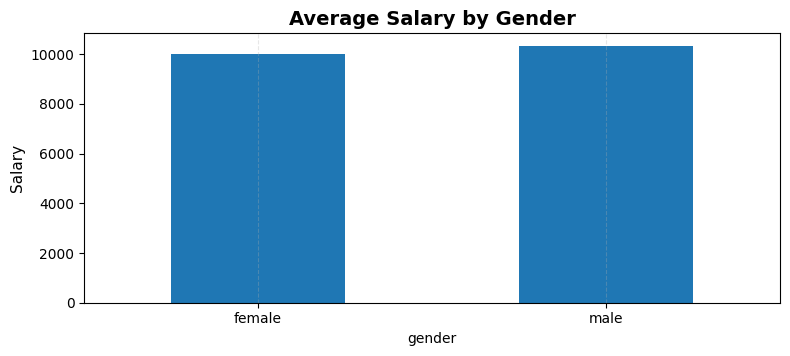

In [47]:
salary_gender = df.groupby("gender")["salary"].mean()

plt.figure(figsize=STANDARD_FIGSIZE)

salary_gender.plot(kind="bar")

format_plot(
    title="Average Salary by Gender",
    ylabel="Salary"
)

plt.xticks(rotation=0)

plt.savefig("../outputs/figures/salary_by_gender.png", dpi=300)
plt.show()

- Masculino: ~10.327  
- Feminino: ~10.006  

Isso representa uma diferença aproximada de **3,2%**.

Apesar de não ser uma discrepância elevada, o resultado sugere um leve desbalanceamento que pode se tornar mais relevante quando analisado em níveis mais granulares, como cargo, área ou senioridade.

Do ponto de vista estatístico, trata-se de uma variação moderada, mas com potencial impacto no contexto organizacional.

## 5. Análise Salarial por Departamento

A média salarial varia entre os departamentos:


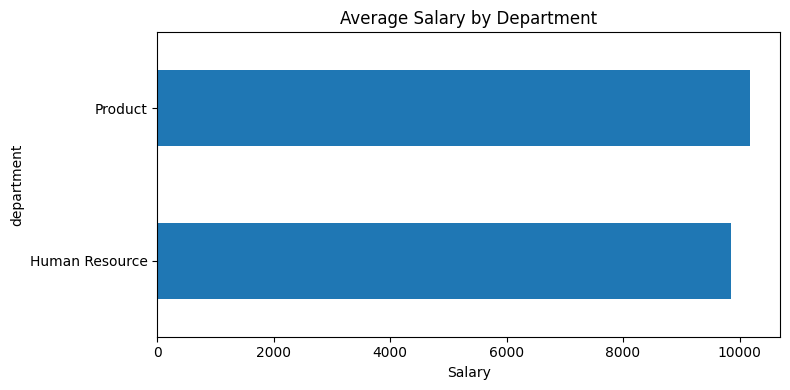

In [48]:
salary_dept = df.groupby("department")["salary"].mean().sort_values()

plt.figure(figsize=(8, 4))  # melhora proporção

salary_dept.plot(kind="barh")

plt.title("Average Salary by Department")
plt.xlabel("Salary")

plt.tight_layout()
plt.savefig("../outputs/figures/salary_by_department.png", dpi=300)  # alta qualidade
plt.show()

- Produto: ~10.185  
- Recursos Humanos: ~9.850  

A diferença observada é de aproximadamente **3,4%**.

Esse intervalo relativamente baixo sugere uma estrutura salarial equilibrada entre áreas. Por outro lado, também pode indicar baixa diferenciação baseada em função ou demanda de mercado.

Uma análise mais aprofundada por nível hierárquico seria necessária para validar a consistência da política de remuneração.

## 6. Relação entre Experiência e Salário

A correlação entre anos de experiência e salário é de aproximadamente **0,89**, indicando uma forte relação positiva.


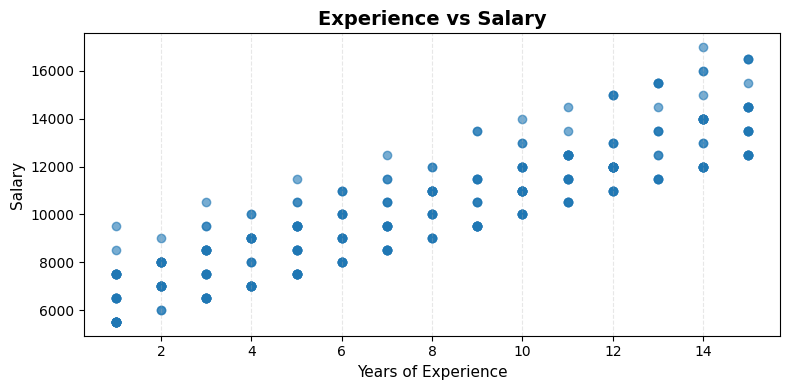

In [49]:
plt.figure(figsize=STANDARD_FIGSIZE)

plt.scatter(df["years_of_experience"], df["salary"], alpha=0.6)

format_plot(
    title="Experience vs Salary",
    xlabel="Years of Experience",
    ylabel="Salary"
)

plt.savefig("../outputs/figures/experience_vs_salary.png", dpi=300)
plt.show()

Na prática:
- Correlações acima de 0,7 já são consideradas fortes  
- Um valor de 0,89 indica uma relação altamente consistente  

Isso sugere que a experiência é um dos principais fatores determinantes na evolução salarial dentro da base analisada.

É importante destacar que correlação não implica causalidade. Outros fatores, como cargo, desempenho e área de atuação, também podem influenciar o salário.

## 7. Top Earners (Maiores Salários)

A análise dos 10 maiores salários da base revela concentração de remuneração em um grupo específico de colaboradores.


In [50]:
top_earners = df.sort_values(by="salary", ascending=False).head(10)
top_earners.to_csv("../outputs/reports/top_earners.csv", index=False)

top_earners

,first_name,last_name,full_name,email,phone,gender,age,job_title,years_of_experience,salary,department,email_valid,phone_clean,phone_valid,phone_error
2,Shawn,Foster,Shawn Foster,shawnfoster2695@slingacademy.com,001-966-861-0065x493,male,37,Project Manager,14,17000,Product,True,NaN,False,invalid_length
151,Austin,Bell,Austin Bell,austinbell151766@slingacademy.com,819-364-7742x938,male,40,DevOps Engineer,15,16500,Product,True,1.819365e+10,True,NaN
59,Aaron,Tran,Aaron Tran,aarontran59178@slingacademy.com,+1-121-704-1976x1624,male,40,DevOps Engineer,15,16500,Product,True,1.121704e+10,True,NaN
96,Patricia,Suarez,Patricia Suarez,patriciasuarez96379@slingacademy.com,(674)788-1168x659,female,41,Designer,15,16500,Product,True,1.674788e+10,True,NaN
123,Logan,Edwards,Logan Edwards,loganedwards123515@slingacademy.com,536.588.4331,male,36,Designer,14,16000,Product,True,1.536588e+10,True,NaN
82,Michael,Davila,Michael Davila,michaeldavila82958@slingacademy.com,9179864827,male,40,DevOps Engineer,14,16000,Product,True,1.917986e+10,True,NaN
204,Michael,Hoover,Michael Hoover,michaelhoover204983@slingacademy.com,(791)222-1972x3424,male,38,DevOps Engineer,13,15500,Product,True,1.791222e+10,True,NaN
42,Alyssa,Archer,Alyssa Archer,alyssaarcher42600@slingacademy.com,001-335-037-7267x43704,female,35,DevOps Engineer,13,15500,Product,True,NaN,False,invalid_length
120,Stephanie,Hill,Stephanie Hill,stephaniehill120240@slingacademy.com,(765)304-0263x230,female,38,DevOps Engineer,15,15500,Product,True,1.765304e+10,True,NaN
124,Ryan,Young,Ryan Young,ryanyoung124775@slingacademy.com,001-105-720-6802x583,male,36,DevOps Engineer,13,15500,Product,True,NaN,False,invalid_length


Observações principais:

- Os maiores salários estão acima de ~17.000, significativamente acima da média geral (~10.000)  
- Isso indica uma variação relevante dentro da distribuição salarial  
- A presença de valores elevados pode sugerir:
  - cargos mais estratégicos ou especializados  
  - níveis mais altos de senioridade  
  - possíveis outliers na base  

Do ponto de vista analítico, essa diferença reforça que a média salarial isolada não captura totalmente a dispersão dos dados.

Uma análise complementar com métricas como mediana e desvio padrão seria recomendada para melhor entendimento da distribuição.

## 7. Análise de Qualidade dos Dados

Foram identificados **63 registros com telefones inválidos**.


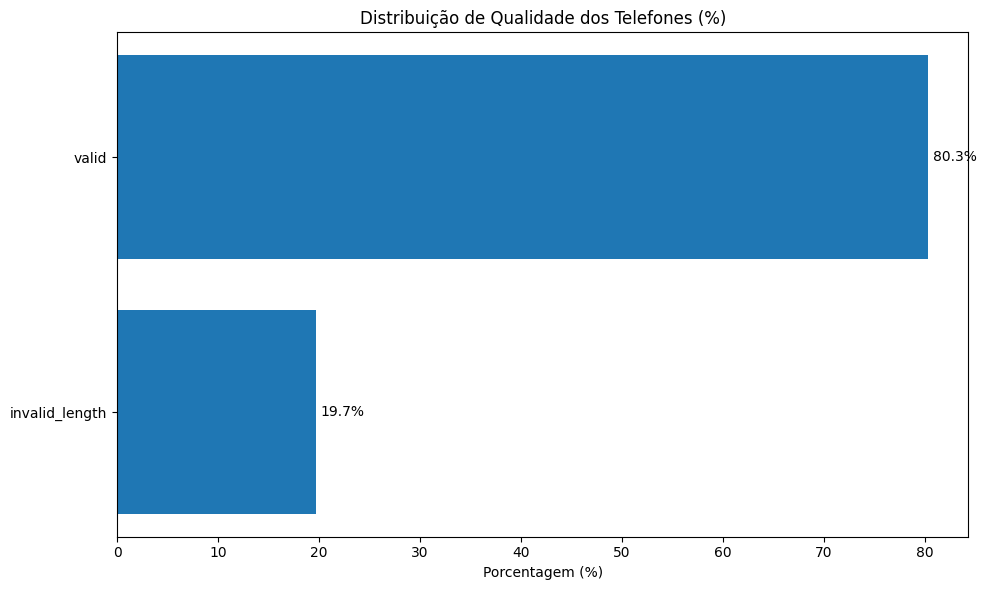

In [51]:
phone_errors = df["phone_error"].value_counts(dropna=False)

phone_errors.index = phone_errors.index.fillna("valid")

phone_errors_pct = (phone_errors / phone_errors.sum()) * 100

phone_errors_pct = phone_errors_pct.sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(phone_errors_pct.index, phone_errors_pct.values)

plt.title("Distribuição de Qualidade dos Telefones (%)")
plt.xlabel("Porcentagem (%)")

for i, v in enumerate(phone_errors_pct.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()

plt.savefig("../outputs/figures/phone_errors_distribution.png", dpi=300)
plt.show()

Considerando um total de aproximadamente 300 registros, isso representa cerca de 21% da base com inconsistências, enquanto aproximadamente 79% dos registros possuem telefones válidos.

Do ponto de vista de negócio, esse nível de inconsistência pode impactar diretamente:

- comunicação com colaboradores
- processos operacionais
- confiabilidade de sistemas dependentes desses dados

A análise evidencia que o erro mais recorrente é "invalid_length", indicando falhas de padronização ou dados incompletos no momento da coleta.

Esse comportamento sugere ausência de validação estruturada na entrada dos dados, o que compromete a qualidade da base ao longo do pipeline.

#### **Recomendação**:
Implementar validação de formato (ex: padrão E.164) no momento da entrada dos dados, reduzindo inconsistências e aumentando a confiabilidade das informações para uso analítico e operacional.

## 8. Principais Insights

- A experiência apresenta forte correlação com o salário (**0,89**), indicando ser o principal fator de progressão salarial  
- Existe uma diferença salarial entre gêneros de aproximadamente **3,2%**, ainda que moderada  
- A variação entre departamentos (~**3,4%**) sugere uma estrutura relativamente uniforme  
- Problemas de qualidade afetam cerca de **21% dos telefones**, representando um risco operacional relevante  

De forma geral, a base apresenta consistência na lógica de remuneração, mas fragilidade na qualidade dos dados.

## 9. Conclusão

A análise demonstra como a aplicação de um pipeline estruturado — envolvendo limpeza, validação e análise — permite gerar insights mais confiáveis.

Do ponto de vista estratégico:
- A progressão salarial está fortemente associada à experiência  
- As diferenças salariais existem, mas não são acentuadas  
- A qualidade dos dados é um ponto crítico que pode comprometer decisões  

Garantir consistência e confiabilidade dos dados é essencial para sustentar análises e apoiar a tomada de decisão.